<a href="https://colab.research.google.com/github/hakeee0331/movie-audience-prediction/blob/Common-Data-Preprocessing/NEW_MLP_only_%EA%B3%B5%ED%86%B5_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EC%A0%84%EC%B2%98%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# #0. 기본 환경 설정

In [ ]:
# ============================================================
# STEP 0. MLP 모델 기본 설정
# ============================================================

print("STEP 0 시작")

import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib

warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount("/content/drive")

BASE_DIR = Path("/content/drive/MyDrive/흥보위")
COMMON_DIR = BASE_DIR / "공통 데이터 전처리"
MODEL_DIR = BASE_DIR / "models"
RESULT_DIR = BASE_DIR / "results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_DATA_PATH = COMMON_DIR / "movie_common_processed.csv"
FEATURE_INFO_PATH = COMMON_DIR / "movie_common_feature_info.pkl"

SEED = 42
N_CLASSES = 4
N_SPLITS = 5

random.seed(SEED)
np.random.seed(SEED)

print("PROCESSED_DATA_PATH:", PROCESSED_DATA_PATH)
print("FEATURE_INFO_PATH:", FEATURE_INFO_PATH)
print("STEP 0 완료")

STEP 0 시작
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROCESSED_DATA_PATH: /content/drive/MyDrive/흥보위/공통 데이터 전처리/movie_common_processed.csv
FEATURE_INFO_PATH: /content/drive/MyDrive/흥보위/공통 데이터 전처리/movie_common_feature_info.pkl
STEP 0 완료


# #1. 공통 데이터 전처리 파일 로드 + MLP feature 구성

In [ ]:
# ============================================================
# STEP 1. 공통 전처리 데이터 로드 / MLP용 feature 구성
# - 시놉시스 feature 제외
# - CNN/포스터 embedding 제외
# ============================================================

print("STEP 1 시작")

# ------------------------------------------------------------
# 1) 공통 전처리 결과 파일 존재 확인
# ------------------------------------------------------------

if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(f"공통 전처리 CSV 파일을 찾을 수 없습니다: {PROCESSED_DATA_PATH}")

if not FEATURE_INFO_PATH.exists():
    raise FileNotFoundError(f"공통 feature info 파일을 찾을 수 없습니다: {FEATURE_INFO_PATH}")

print("공통 전처리 파일 확인 완료")
print("PROCESSED_DATA_PATH:", PROCESSED_DATA_PATH)
print("FEATURE_INFO_PATH:", FEATURE_INFO_PATH)


# ------------------------------------------------------------
# 2) 공통 전처리 데이터 로드
# ------------------------------------------------------------

df = pd.read_csv(PROCESSED_DATA_PATH)
feature_info = joblib.load(FEATURE_INFO_PATH)

print("\n공통 전처리 데이터 로드 완료")
print("df shape:", df.shape)

print("\nfeature_info keys:")
print(feature_info.keys())


# ------------------------------------------------------------
# 3) 공통 feature 목록 불러오기
# ------------------------------------------------------------

common_numeric_features = feature_info["numeric_features"]
common_categorical_features = feature_info["categorical_features"]
common_genre_cols = feature_info["genre_cols"]
common_feature_cols = feature_info["feature_cols"]

print("\n공통 feature 수:")
print("numeric_features:", len(common_numeric_features))
print("categorical_features:", len(common_categorical_features))
print("genre_cols:", len(common_genre_cols))
print("feature_cols:", len(common_feature_cols))


# ------------------------------------------------------------
# 4) 이번 MLP 모델에서 제외할 feature 정의
# ------------------------------------------------------------
# 이번 모델은 시놉시스 미포함 버전이므로 시놉시스 관련 feature를 제거한다.
# CNN 포스터 embedding은 애초에 common_feature_cols에 없지만,
# 포스터_보유여부도 이미지/포스터 관련 신호이므로 이번 순수 메타데이터 MLP에서는 제외한다.

synopsis_exclude_features = [
    "시놉시스_prob_0",
    "시놉시스_prob_1",
    "시놉시스_prob_2",
    "시놉시스_prob_3",
    "시놉시스_pred_class",
    "시놉시스_confidence",
    "시놉시스_보유여부"
]

poster_exclude_features = [
    "포스터_보유여부"
]

# 혹시 이전 버전 feature_info에 남아 있을 수 있는 무의미/제거 대상 feature
optional_exclude_features = [
    "배우_점수",
    "감독_점수",
    "배우수",
    "감독수",
    "제작사수",
    "배급사수"
]

exclude_features = (
    synopsis_exclude_features
    + poster_exclude_features
    + optional_exclude_features
)

print("\n이번 MLP에서 제외할 feature:")
print(exclude_features)


# ------------------------------------------------------------
# 5) MLP-only feature 목록 생성
# ------------------------------------------------------------

numeric_features = [
    col for col in common_numeric_features
    if col not in exclude_features
]

categorical_features = [
    col for col in common_categorical_features
    if col not in exclude_features
]

genre_cols = [
    col for col in common_genre_cols
    if col not in exclude_features
]

feature_cols = numeric_features + categorical_features + genre_cols

# 중복 제거: 순서 유지
feature_cols = list(dict.fromkeys(feature_cols))

print("\nMLP-only feature 수:")
print("numeric_features:", len(numeric_features))
print("categorical_features:", len(categorical_features))
print("genre_cols:", len(genre_cols))
print("feature_cols:", len(feature_cols))

print("\nMLP-only numeric_features:")
print(numeric_features)

print("\nMLP-only categorical_features:")
print(categorical_features)

print("\nMLP-only genre_cols:")
print(genre_cols)


# ------------------------------------------------------------
# 6) feature 존재 여부 확인
# ------------------------------------------------------------

missing_features = [col for col in feature_cols if col not in df.columns]

if len(missing_features) > 0:
    raise ValueError(f"df에 없는 feature가 있습니다: {missing_features}")

print("\nfeature 존재 여부 확인 완료")


# ------------------------------------------------------------
# 7) target 생성
# ------------------------------------------------------------

X = df[feature_cols].copy()
y_class = df["y_class"].astype(int).copy()
y_reg_log = df["y_reg_log"].astype(float).copy()

print("\nX, y 생성 완료")
print("X shape:", X.shape)
print("y_class shape:", y_class.shape)
print("y_reg_log shape:", y_reg_log.shape)


# ------------------------------------------------------------
# 8) target 분포 확인
# ------------------------------------------------------------

print("\ny_class 분포:")
class_dist = (
    y_class.value_counts()
    .sort_index()
    .reset_index()
)

class_dist.columns = ["y_class", "count"]

if "CLASS_BINS" in feature_info:
    class_name_map = feature_info["CLASS_BINS"]
elif "class_name_map" in feature_info:
    class_name_map = feature_info["class_name_map"]
else:
    class_name_map = {
        0: "1만 미만",
        1: "1만~10만",
        2: "10만~100만",
        3: "100만 이상"
    }

# pkl/json 저장 과정에 따라 key가 문자열일 수도 있으므로 보정
class_name_map = {int(k): v for k, v in class_name_map.items()}

class_dist["class_name"] = class_dist["y_class"].map(class_name_map)
class_dist["ratio"] = class_dist["count"] / len(df)

display(class_dist)


print("\ny_reg_log 통계:")
display(y_reg_log.describe().reset_index().rename(
    columns={"index": "stat", "y_reg_log": "value"}
))


# ------------------------------------------------------------
# 9) 결측치 확인
# ------------------------------------------------------------

feature_missing_count = X.isna().sum().sum()

print("\nX 전체 결측치 개수:", feature_missing_count)

if feature_missing_count > 0:
    print("\n결측치가 있는 feature:")
    display(
        X.isna()
        .sum()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"index": "feature", 0: "missing_count"})
        .query("missing_count > 0")
    )
    raise ValueError("X에 결측치가 있습니다.")

print("X 결측치 없음 확인 완료")


# ------------------------------------------------------------
# 10) 사용하지 않는 주요 컬럼 확인
# ------------------------------------------------------------

not_used_but_saved_cols = [
    "영화명",
    "누적관객수",
    "y_class",
    "y_class_name",
    "y_reg_log",
    "시놉시스",
    "포스터URL"
]

print("\n저장은 되어 있지만 이번 MLP 입력 feature로는 쓰지 않는 주요 컬럼:")
for col in not_used_but_saved_cols:
    if col in df.columns:
        print(f"- {col}: feature 사용 여부 = {col in feature_cols}")


print("\nSTEP 1 완료")

STEP 1 시작
공통 전처리 파일 확인 완료
PROCESSED_DATA_PATH: /content/drive/MyDrive/흥보위/공통 데이터 전처리/movie_common_processed.csv
FEATURE_INFO_PATH: /content/drive/MyDrive/흥보위/공통 데이터 전처리/movie_common_feature_info.pkl

공통 전처리 데이터 로드 완료
df shape: (5093, 67)

feature_info keys:
dict_keys(['SEED', 'START_DATE', 'END_DATE', 'CLASS_BINS', 'USE_LEAKAGE_FEATURES', 'id_cols', 'target_cols', 'numeric_features', 'categorical_features', 'genre_cols', 'feature_cols', 'auxiliary_cols', 'save_cols', 'n_numeric_features', 'n_categorical_features', 'n_genre_cols', 'n_feature_cols', 'class_name_map', 'n_classes', 'poster_join_key', 'synopsis_prob_cols', 'leakage_features'])

공통 feature 수:
numeric_features: 29
categorical_features: 5
genre_cols: 21
feature_cols: 55

이번 MLP에서 제외할 feature:
['시놉시스_prob_0', '시놉시스_prob_1', '시놉시스_prob_2', '시놉시스_prob_3', '시놉시스_pred_class', '시놉시스_confidence', '시놉시스_보유여부', '포스터_보유여부', '배우_점수', '감독_점수', '배우수', '감독수', '제작사수', '배급사수']

MLP-only feature 수:
numeric_features: 21
categorical_features: 5


,y_class,count,class_name,ratio
0,0,2422,1만 미만,0.475555
1,1,1630,1만~10만,0.320047
2,2,695,10만~100만,0.136462
3,3,346,100만 이상,0.067936



y_reg_log 통계:


,stat,value
0,count,5093.000000
1,mean,9.736085
2,std,2.249282
3,min,4.882802
4,25%,8.076205
5,50%,9.319822
6,75%,10.998778
7,max,16.604627



X 전체 결측치 개수: 0
X 결측치 없음 확인 완료

저장은 되어 있지만 이번 MLP 입력 feature로는 쓰지 않는 주요 컬럼:
- 영화명: feature 사용 여부 = False
- 누적관객수: feature 사용 여부 = False
- y_class: feature 사용 여부 = False
- y_class_name: feature 사용 여부 = False
- y_reg_log: feature 사용 여부 = False
- 시놉시스: feature 사용 여부 = False
- 포스터URL: feature 사용 여부 = False

STEP 1 완료


# #2. MLP용 전처리기 / 모델 함수 정의

In [ ]:
# ============================================================
# STEP 2. MLP용 전처리기 / 모델 함수 정의
# - 시놉시스 feature 미포함
# - CNN feature 미포함
# - Multi-task MLP: class 분류 + log 관객수 회귀
# ============================================================

print("STEP 2 시작")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers


# ------------------------------------------------------------
# 1) TensorFlow seed 고정
# ------------------------------------------------------------

tf.random.set_seed(SEED)


# ------------------------------------------------------------
# 2) OneHotEncoder 호환 함수
# ------------------------------------------------------------
# sklearn 버전에 따라 sparse_output 또는 sparse 인자를 사용해야 해서
# 오류가 나지 않도록 함수로 처리한다.

def make_onehot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            max_categories=30,
            sparse_output=False
        )
    except TypeError:
        try:
            return OneHotEncoder(
                handle_unknown="ignore",
                max_categories=30,
                sparse=False
            )
        except TypeError:
            return OneHotEncoder(
                handle_unknown="ignore",
                sparse=False
            )


# ------------------------------------------------------------
# 3) MLP용 전처리기 생성 함수
# ------------------------------------------------------------
# numeric_features:
#   결측치 median 대체 → StandardScaler
#
# categorical_features:
#   결측치 Unknown 대체 → OneHotEncoder
#
# genre_cols:
#   이미 0/1 multi-hot이므로 그대로 통과

def build_preprocessor(numeric_features, categorical_features, genre_cols):
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("onehot", make_onehot_encoder())
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
            ("genre", "passthrough", genre_cols)
        ],
        remainder="drop"
    )

    return preprocessor


# ------------------------------------------------------------
# 4) Multi-task MLP 모델 생성 함수
# ------------------------------------------------------------
# 입력:
#   공통 전처리 feature를 MLP 입력용으로 변환한 벡터
#
# 출력:
#   class_out: 흥행 등급 4-class 분류
#   reg_out: log 관객수 회귀

def build_mlp_multitask(input_dim, n_classes=N_CLASSES):
    inputs = layers.Input(shape=(input_dim,), name="metadata_features")

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    )(x)

    class_out = layers.Dense(
        n_classes,
        activation="softmax",
        name="class_out"
    )(x)

    reg_out = layers.Dense(
        1,
        activation="linear",
        name="reg_out"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs={
            "class_out": class_out,
            "reg_out": reg_out
        }
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss={
            "class_out": "sparse_categorical_crossentropy",
            "reg_out": "mse"
        },
        loss_weights={
            "class_out": 1.0,
            "reg_out": 0.1
        },
        metrics={
            "class_out": ["accuracy"],
            "reg_out": ["mae"]
        }
    )

    return model


# ------------------------------------------------------------
# 5) 함수 작동 간단 확인
# ------------------------------------------------------------

test_preprocessor = build_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    genre_cols=genre_cols
)

print("전처리기 생성 테스트 완료")
print("numeric_features:", len(numeric_features))
print("categorical_features:", len(categorical_features))
print("genre_cols:", len(genre_cols))

# input_dim은 아직 실제 fit 전에는 모른다.
# 임시 input_dim으로 모델 구조만 확인한다.
test_model = build_mlp_multitask(
    input_dim=100,
    n_classes=N_CLASSES
)

print("\n모델 생성 테스트 완료")
test_model.summary()

print("\nDense = Hiddne Layer\nBatchNormalization = 학습을 안정화\nDropout = 일부 뉴런을 무작위로 꺼서 과적합을 줄이는 역할")
print("\nTotal Params는 모델이 학습할 가중치 수 > 총 24,197개")
print("\nSTEP 2 완료")

STEP 2 시작
전처리기 생성 테스트 완료
numeric_features: 21
categorical_features: 5
genre_cols: 21

모델 생성 테스트 완료


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ metadata_features   │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 128)       │     12,928 │ metadata_feature… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_24[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 64)        │      8,256 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_25[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 32)        │      2,080 │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_out (Dense)   │ (None, 4)         │        132 │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_out (Dense)     │ (None, 1)         │         33 │ dense_26[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,197 (94.52 KB)

 Trainable params: 23,813 (93.02 KB)

 Non-trainable params: 384 (1.50 KB)


Dense = Hiddne Layer
BatchNormalization = 학습을 안정화
Dropout = 일부 뉴런을 무작위로 꺼서 과적합을 줄이는 역할

Total Params는 모델이 학습할 가중치 수 > 총 24,197개

STEP 2 완료


# #3. 5-Fold OOF 학습/평가

In [ ]:
# ============================================================
# STEP 3. 5-Fold OOF 학습 / 평가
# - 시놉시스 feature 미포함
# - CNN feature 미포함
# - 순수 메타데이터 기반 Multi-task MLP
# ============================================================

print("STEP 3 시작")

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1) OOF 저장 공간 생성
# ------------------------------------------------------------

n_samples = len(X)

oof_class_probs = np.zeros((n_samples, N_CLASSES))
oof_reg_preds = np.zeros(n_samples)

fold_metrics = []
fold_histories = []
fold_models = []
fold_preprocessors = []

print("n_samples:", n_samples)
print("oof_class_probs shape:", oof_class_probs.shape)
print("oof_reg_preds shape:", oof_reg_preds.shape)


# ------------------------------------------------------------
# 2) Stratified K-Fold 설정
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

print("\nStratifiedKFold 설정 완료")
print("N_SPLITS:", N_SPLITS)


# ------------------------------------------------------------
# 3) Fold별 학습
# ------------------------------------------------------------

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y_class), start=1):
    print("\n" + "=" * 80)
    print(f"MLP FOLD {fold}/{N_SPLITS}")
    print("=" * 80)

    # --------------------------------------------------------
    # 3-1) train / valid 분리
    # --------------------------------------------------------

    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()

    y_train_class = y_class.iloc[train_idx].copy()
    y_valid_class = y_class.iloc[valid_idx].copy()

    y_train_reg = y_reg_log.iloc[train_idx].copy()
    y_valid_reg = y_reg_log.iloc[valid_idx].copy()

    print("Train size:", len(X_train))
    print("Valid size:", len(X_valid))

    print("\nTrain class 분포:")
    print(y_train_class.value_counts().sort_index())

    print("\nValid class 분포:")
    print(y_valid_class.value_counts().sort_index())


    # --------------------------------------------------------
    # 3-2) 전처리기 fit/transform
    # --------------------------------------------------------
    # 주의:
    # preprocessor는 train fold에만 fit하고,
    # valid fold에는 transform만 적용한다.

    preprocessor = build_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        genre_cols=genre_cols
    )

    X_train_processed = preprocessor.fit_transform(X_train)
    X_valid_processed = preprocessor.transform(X_valid)

    X_train_processed = X_train_processed.astype(np.float32)
    X_valid_processed = X_valid_processed.astype(np.float32)

    print("\n전처리 후 shape:")
    print("X_train_processed:", X_train_processed.shape)
    print("X_valid_processed:", X_valid_processed.shape)


    # --------------------------------------------------------
    # 3-3) 모델 생성
    # --------------------------------------------------------

    input_dim = X_train_processed.shape[1]

    model = build_mlp_multitask(
        input_dim=input_dim,
        n_classes=N_CLASSES
    )

    print("\n모델 input_dim:", input_dim)


    # --------------------------------------------------------
    # 3-4) Callback 설정
    # --------------------------------------------------------

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-5,
        verbose=1
    )


    # --------------------------------------------------------
    # 3-5) 모델 학습
    # --------------------------------------------------------

    history = model.fit(
        X_train_processed,
        {
            "class_out": y_train_class.values,
            "reg_out": y_train_reg.values
        },
        validation_data=(
            X_valid_processed,
            {
                "class_out": y_valid_class.values,
                "reg_out": y_valid_reg.values
            }
        ),
        epochs=200,
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    fold_histories.append(history)


    # --------------------------------------------------------
    # 3-6) validation 예측
    # --------------------------------------------------------

    valid_pred = model.predict(
        X_valid_processed,
        batch_size=256,
        verbose=0
    )

    if isinstance(valid_pred, dict):
        valid_class_probs = valid_pred["class_out"]
        valid_reg_pred = valid_pred["reg_out"].reshape(-1)
    else:
        valid_class_probs = valid_pred[0]
        valid_reg_pred = valid_pred[1].reshape(-1)

    valid_class_pred = np.argmax(valid_class_probs, axis=1)

    oof_class_probs[valid_idx] = valid_class_probs
    oof_reg_preds[valid_idx] = valid_reg_pred


    # --------------------------------------------------------
    # 3-7) Fold 성능 계산
    # --------------------------------------------------------

    fold_acc = accuracy_score(y_valid_class, valid_class_pred)
    fold_f1_macro = f1_score(
        y_valid_class,
        valid_class_pred,
        average="macro",
        zero_division=0
    )
    fold_f1_weighted = f1_score(
        y_valid_class,
        valid_class_pred,
        average="weighted",
        zero_division=0
    )

    fold_r2_log = r2_score(y_valid_reg, valid_reg_pred)
    fold_mae_log = mean_absolute_error(y_valid_reg, valid_reg_pred)
    fold_rmse_log = np.sqrt(mean_squared_error(y_valid_reg, valid_reg_pred))

    y_valid_actual = np.expm1(y_valid_reg.values)
    valid_pred_actual = np.expm1(valid_reg_pred)
    valid_pred_actual = np.clip(valid_pred_actual, 0, None)

    fold_mae_actual = mean_absolute_error(y_valid_actual, valid_pred_actual)
    fold_rmse_actual = np.sqrt(mean_squared_error(y_valid_actual, valid_pred_actual))

    fold_metric = {
        "fold": fold,
        "accuracy": fold_acc,
        "f1_macro": fold_f1_macro,
        "f1_weighted": fold_f1_weighted,
        "r2_log": fold_r2_log,
        "mae_log": fold_mae_log,
        "rmse_log": fold_rmse_log,
        "mae_actual": fold_mae_actual,
        "rmse_actual": fold_rmse_actual,
        "epochs": len(history.history["loss"]),
        "input_dim": input_dim
    }

    fold_metrics.append(fold_metric)

    print("\n[MLP FOLD 성능]")
    for k, v in fold_metric.items():
        if k in ["fold", "epochs", "input_dim"]:
            print(f"{k}: {v}")
        else:
            print(f"{k}: {v:.4f}")

    fold_models.append(model)
    fold_preprocessors.append(preprocessor)


# ------------------------------------------------------------
# 4) Fold별 성능 요약
# ------------------------------------------------------------

fold_metrics_df = pd.DataFrame(fold_metrics)

print("\n" + "=" * 80)
print("STEP 3 완료: Fold별 성능 요약")
print("=" * 80)

display(fold_metrics_df)

print("\n평균 / 표준편차:")
display(
    fold_metrics_df
    .drop(columns=["fold"])
    .agg(["mean", "std"])
)


# ------------------------------------------------------------
# 5) 결과 저장
# ------------------------------------------------------------

mlp_fold_metrics_path = RESULT_DIR / "mlp_no_synopsis_no_cnn_fold_metrics.csv"

fold_metrics_df.to_csv(
    mlp_fold_metrics_path,
    index=False,
    encoding="utf-8-sig"
)

print("\n저장 완료:")
print(mlp_fold_metrics_path)

print("\nSTEP 3 완료")

STEP 3 시작
n_samples: 5093
oof_class_probs shape: (5093, 4)
oof_reg_preds shape: (5093,)

StratifiedKFold 설정 완료
N_SPLITS: 5

MLP FOLD 1/5
Train size: 4074
Valid size: 1019

Train class 분포:
y_class
0    1937
1    1304
2     556
3     277
Name: count, dtype: int64

Valid class 분포:
y_class
0    485
1    326
2    139
3     69
Name: count, dtype: int64

전처리 후 shape:
X_train_processed: (4074, 168)
X_valid_processed: (1019, 168)

모델 input_dim: 168
Epoch 1/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - class_out_accuracy: 0.4413 - class_out_loss: 1.2922 - loss: 6.5778 - reg_out_loss: 50.1622 - reg_out_mae: 6.5771 - val_class_out_accuracy: 0.5486 - val_class_out_loss: 1.0653 - val_loss: 6.6988 - val_reg_out_loss: 53.8623 - val_reg_out_mae: 7.1025 - learning_rate: 0.0010
Epoch 2/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - class_out_accuracy: 0.5432 - class_out_loss: 1.0402 - loss: 2.1171 - reg_out_loss: 8.3054 - reg_out_mae: 2.2764 - val_class_out_accuracy: 0.5878 - val_class_out_loss: 0.9556 - v

,fold,accuracy,f1_macro,f1_weighted,r2_log,mae_log,rmse_log,mae_actual,rmse_actual,epochs,input_dim
0,1,0.635918,0.611034,0.632057,0.593010,1.129648,1.430148,364474.886120,4.547418e+06,34,168
1,2,0.638862,0.591420,0.628766,0.595513,1.133897,1.419341,221898.654640,9.159398e+05,42,169
2,3,0.612365,0.562895,0.601410,0.551490,1.173011,1.499343,228935.631959,9.242580e+05,42,169
3,4,0.634578,0.571329,0.624378,0.574544,1.166471,1.492967,209197.655510,7.587821e+05,41,170
4,5,0.642436,0.599713,0.631560,0.589044,1.125217,1.438114,350000.980580,3.641971e+06,39,170



평균 / 표준편차:


,accuracy,f1_macro,f1_weighted,r2_log,mae_log,rmse_log,mae_actual,rmse_actual,epochs,input_dim
mean,0.632832,0.587278,0.623634,0.580720,1.145649,1.455982,274901.561762,2.157674e+06,39.600000,169.20000
std,0.011833,0.019906,0.012792,0.018246,0.022326,0.037341,75667.828874,1.798203e+06,3.361547,0.83666



저장 완료:
/content/drive/MyDrive/흥보위/results/mlp_no_synopsis_no_cnn_fold_metrics.csv

STEP 3 완료


# #4. OOF 전체 성능 평가 / 결과 저장

STEP 4 시작
oof_class_probs shape: (5093, 4)
oof_class_pred shape: (5093,)
oof_reg_preds shape: (5093,)

[OOF Classification 성능]
Accuracy: 0.6328293736501079
F1 Macro: 0.5873806272526605
F1 Weighted: 0.6239306497605764

[Classification Report]
              precision    recall  f1-score   support

       1만 미만       0.71      0.81      0.76      2422
      1만~10만       0.53      0.45      0.48      1630
    10만~100만       0.51      0.48      0.50       695
     100만 이상       0.70      0.54      0.61       346

    accuracy                           0.63      5093
   macro avg       0.61      0.57      0.59      5093
weighted avg       0.62      0.63      0.62      5093


[Confusion Matrix]
[[1972  411   33    6]
 [ 729  726  160   15]
 [  83  215  337   60]
 [   8   23  127  188]]


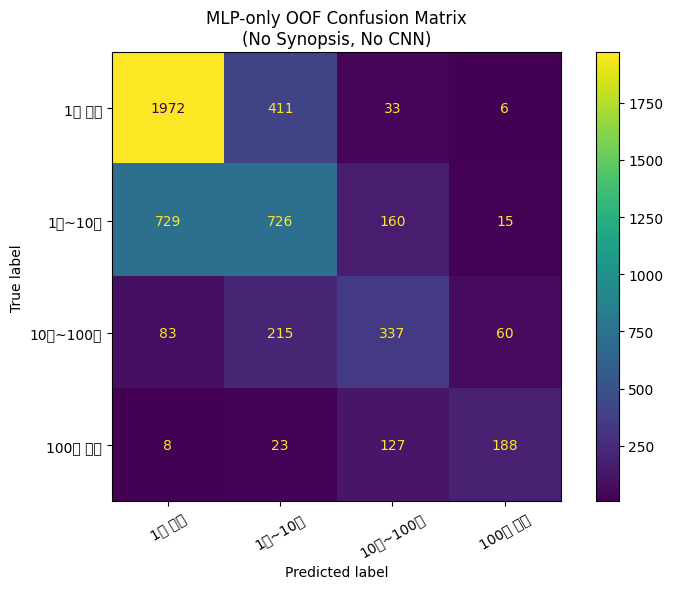


[OOF Regression 성능 - log scale]
R2 Log: 0.5806890976107772
MAE Log: 1.1456488123671522
RMSE Log: 1.456361781420216

[OOF Regression 성능 - actual audience scale]
MAE Actual: 274899.7159746273
RMSE Actual: 2691191.0718350783

[OOF 전체 성능 요약]


,model,n_samples,n_features,accuracy,f1_macro,f1_weighted,r2_log,mae_log,rmse_log,mae_actual,rmse_actual
0,MLP-only_no_synopsis_no_cnn,5093,47,0.632829,0.587381,0.623931,0.580689,1.145649,1.456362,274899.715975,2.691191e+06



OOF 예측 결과 예시:


,original_index,영화명,개봉일,누적관객수,y_class,y_class_name,y_reg_log,pred_class,pred_class_name,pred_prob_0,pred_prob_1,pred_prob_2,pred_prob_3,pred_reg_log,pred_audience,class_correct,abs_log_error,abs_audience_error,class_diff,abs_class_diff
0,0,#런석진_에피소드. 투어 더 무비,2025-12-31,9584,0,1만 미만,9.167955,0,1만 미만,0.794528,0.192548,0.012721,0.000203,8.621540,5549,1,0.546415,4035,0,0
1,1,#살아있다,2020-06-24,1903992,3,100만 이상,14.459464,2,10만~100만,0.063812,0.346881,0.476152,0.113155,12.019167,165903,0,2.440297,1738089,-1,1
2,2,#아이엠히어,2021-01-14,16404,1,1만~10만,9.705341,1,1만~10만,0.277119,0.561669,0.117482,0.043730,9.487095,13187,1,0.218247,3217,0,0
3,3,#위왓치유,2021-06-03,1908,0,1만 미만,7.554335,0,1만 미만,0.893447,0.104119,0.001446,0.000988,6.873981,966,1,0.680354,942,0,0
4,4,#진상을 말씀드립니다,2025-09-24,7002,0,1만 미만,8.854094,0,1만 미만,0.821338,0.171009,0.007404,0.000250,8.060602,3166,1,0.793492,3836,0,0
5,5,(여자)아이들 월드투어 [아이돌] 인 시네마,2025-01-08,5294,0,1만 미만,8.574518,1,1만~10만,0.354903,0.516437,0.126930,0.001730,10.378799,32169,0,1.804281,26875,1,1
6,6,0.0MHz,2019-05-29,137294,2,10만~100만,11.829887,1,1만~10만,0.050390,0.601556,0.252947,0.095107,11.193600,72663,0,0.636287,64631,-1,1
7,7,007 노 타임 투 다이,2021-09-29,1229971,3,100만 이상,14.022502,2,10만~100만,0.054025,0.151596,0.611402,0.182976,13.314238,605758,0,0.708264,624213,-1,1
8,8,10 라이브즈,2024-08-15,60606,1,1만~10만,11.012166,1,1만~10만,0.209273,0.761082,0.026889,0.002756,11.020979,61143,1,0.008813,537,0,0
9,9,100 미터.,2025-10-08,39557,1,1만~10만,10.585523,1,1만~10만,0.127323,0.591590,0.279085,0.002002,11.124137,67787,1,0.538614,28230,0,0



저장 완료:
OOF metrics: /content/drive/MyDrive/흥보위/results/mlp_no_synopsis_no_cnn_oof_metrics.csv
OOF predictions: /content/drive/MyDrive/흥보위/results/mlp_no_synopsis_no_cnn_oof_predictions.csv
Confusion matrix: /content/drive/MyDrive/흥보위/results/mlp_no_synopsis_no_cnn_confusion_matrix.csv

STEP 4 완료


In [ ]:
# ============================================================
# STEP 4. OOF 전체 성능 평가 / 결과 저장
# - 시놉시스 feature 미포함
# - CNN feature 미포함
# - 순수 메타데이터 기반 MLP
# ============================================================

print("STEP 4 시작")

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# ------------------------------------------------------------
# 1) OOF class 예측값 생성
# ------------------------------------------------------------

oof_class_pred = np.argmax(oof_class_probs, axis=1)

print("oof_class_probs shape:", oof_class_probs.shape)
print("oof_class_pred shape:", oof_class_pred.shape)
print("oof_reg_preds shape:", oof_reg_preds.shape)


# ------------------------------------------------------------
# 2) 전체 classification 성능
# ------------------------------------------------------------

overall_accuracy = accuracy_score(y_class, oof_class_pred)

overall_f1_macro = f1_score(
    y_class,
    oof_class_pred,
    average="macro",
    zero_division=0
)

overall_f1_weighted = f1_score(
    y_class,
    oof_class_pred,
    average="weighted",
    zero_division=0
)

print("\n[OOF Classification 성능]")
print("Accuracy:", overall_accuracy)
print("F1 Macro:", overall_f1_macro)
print("F1 Weighted:", overall_f1_weighted)


# ------------------------------------------------------------
# 3) Classification report
# ------------------------------------------------------------

target_names = [
    class_name_map[0],
    class_name_map[1],
    class_name_map[2],
    class_name_map[3]
]

print("\n[Classification Report]")
print(
    classification_report(
        y_class,
        oof_class_pred,
        target_names=target_names,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 4) Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_class, oof_class_pred)

print("\n[Confusion Matrix]")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=30
)
plt.title("MLP-only OOF Confusion Matrix\n(No Synopsis, No CNN)")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5) Regression 성능: log scale
# ------------------------------------------------------------

overall_r2_log = r2_score(y_reg_log, oof_reg_preds)
overall_mae_log = mean_absolute_error(y_reg_log, oof_reg_preds)
overall_rmse_log = np.sqrt(mean_squared_error(y_reg_log, oof_reg_preds))

print("\n[OOF Regression 성능 - log scale]")
print("R2 Log:", overall_r2_log)
print("MAE Log:", overall_mae_log)
print("RMSE Log:", overall_rmse_log)


# ------------------------------------------------------------
# 6) Regression 성능: actual audience scale
# ------------------------------------------------------------

y_actual = np.expm1(y_reg_log.values)

oof_pred_actual = np.expm1(oof_reg_preds)
oof_pred_actual = np.clip(oof_pred_actual, 0, None)

overall_mae_actual = mean_absolute_error(y_actual, oof_pred_actual)
overall_rmse_actual = np.sqrt(mean_squared_error(y_actual, oof_pred_actual))

print("\n[OOF Regression 성능 - actual audience scale]")
print("MAE Actual:", overall_mae_actual)
print("RMSE Actual:", overall_rmse_actual)


# ------------------------------------------------------------
# 7) 최종 OOF metric table 생성
# ------------------------------------------------------------

mlp_oof_metrics = {
    "model": "MLP-only_no_synopsis_no_cnn",
    "n_samples": len(df),
    "n_features": len(feature_cols),
    "accuracy": overall_accuracy,
    "f1_macro": overall_f1_macro,
    "f1_weighted": overall_f1_weighted,
    "r2_log": overall_r2_log,
    "mae_log": overall_mae_log,
    "rmse_log": overall_rmse_log,
    "mae_actual": overall_mae_actual,
    "rmse_actual": overall_rmse_actual
}

mlp_oof_metrics_df = pd.DataFrame([mlp_oof_metrics])

print("\n[OOF 전체 성능 요약]")
display(mlp_oof_metrics_df)


# ------------------------------------------------------------
# 8) OOF 예측 결과 DataFrame 생성
# ------------------------------------------------------------

oof_result_df = df[
    [
        "original_index",
        "영화명",
        "개봉일",
        "누적관객수",
        "y_class",
        "y_class_name",
        "y_reg_log"
    ]
].copy()

oof_result_df["pred_class"] = oof_class_pred
oof_result_df["pred_class_name"] = oof_result_df["pred_class"].map(class_name_map)

for i in range(N_CLASSES):
    oof_result_df[f"pred_prob_{i}"] = oof_class_probs[:, i]

oof_result_df["pred_reg_log"] = oof_reg_preds
oof_result_df["pred_audience"] = oof_pred_actual
oof_result_df["pred_audience"] = oof_result_df["pred_audience"].round().astype(int)

oof_result_df["class_correct"] = (
    oof_result_df["y_class"] == oof_result_df["pred_class"]
).astype(int)

oof_result_df["abs_log_error"] = np.abs(
    oof_result_df["y_reg_log"] - oof_result_df["pred_reg_log"]
)

oof_result_df["abs_audience_error"] = np.abs(
    oof_result_df["누적관객수"] - oof_result_df["pred_audience"]
)

oof_result_df["class_diff"] = (
    oof_result_df["pred_class"] - oof_result_df["y_class"]
)

oof_result_df["abs_class_diff"] = oof_result_df["class_diff"].abs()

print("\nOOF 예측 결과 예시:")
display(oof_result_df.head(10))


# ------------------------------------------------------------
# 9) 저장
# ------------------------------------------------------------

mlp_oof_metrics_path = RESULT_DIR / "mlp_no_synopsis_no_cnn_oof_metrics.csv"
mlp_oof_predictions_path = RESULT_DIR / "mlp_no_synopsis_no_cnn_oof_predictions.csv"
mlp_confusion_matrix_path = RESULT_DIR / "mlp_no_synopsis_no_cnn_confusion_matrix.csv"

mlp_oof_metrics_df.to_csv(
    mlp_oof_metrics_path,
    index=False,
    encoding="utf-8-sig"
)

oof_result_df.to_csv(
    mlp_oof_predictions_path,
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame(
    cm,
    index=target_names,
    columns=target_names
).to_csv(
    mlp_confusion_matrix_path,
    encoding="utf-8-sig"
)

print("\n저장 완료:")
print("OOF metrics:", mlp_oof_metrics_path)
print("OOF predictions:", mlp_oof_predictions_path)
print("Confusion matrix:", mlp_confusion_matrix_path)

print("\nSTEP 4 완료")